In [10]:
import os
import cv2, tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from sklearn.utils import shuffle
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

In [11]:
image_dir = 'input/train'
train_folders = os.listdir(image_dir)

In [12]:
print(f"Min files in a folder: {min([len([f for f in os.listdir(os.path.join(image_dir, fldr)) if os.path.isfile(os.path.join(image_dir, fldr, f))]) for fldr in train_folders])}")
total_images = sum(
    len([f for f in os.listdir(os.path.join(image_dir, fldr)) if os.path.isfile(os.path.join(image_dir, fldr, f))])
    for fldr in train_folders
)
print(f"Total images: {total_images}")

Min files in a folder: 108
Total images: 7624


In [13]:
Sx = 100
Sy = 100
epocas = 20

In [14]:
def exploreData (folders) :
    plt.figure(figsize=(10,10))
    for i,fol in tqdm.tqdm(enumerate(folders[:25])) :
        plt.subplot(5,5 ,i+1)
        image = os.listdir(os.path.join(image_dir,fol))[0]
        imgPath = os.path.join(image_dir,fol,image)
        img = cv2.imread(imgPath)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        plt.title(fol)
        plt.imshow(imgRGB)
    plt.show()

25it [00:00, 39.76it/s]


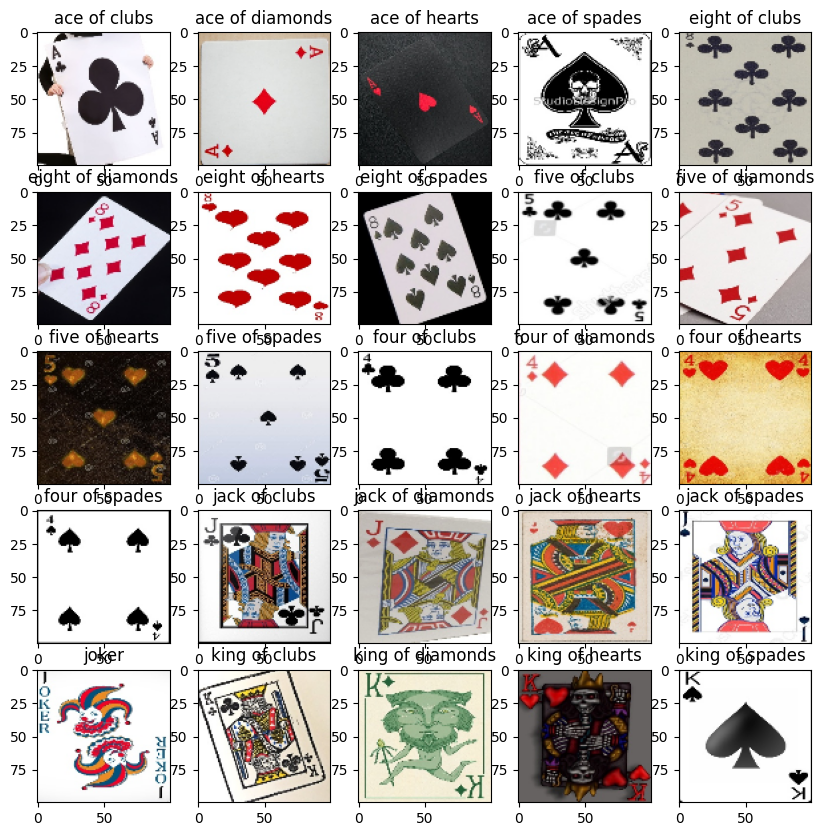

In [15]:
exploreData(train_folders)

In [16]:
train_size = 100
test_size = 20

In [17]:
x_test_RGB = []
y_test_RGB = []
x_valid_RGB = []
y_valid_RGB = []
x_train_RGB = []
y_train_RGB = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[:test_size]
    test_images = images_in_folder[test_size:]
    train_images = images_in_folder[train_size:]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_test_RGB.append(imgRGB)
        y_test_RGB.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_valid_RGB.append(imgRGB)
        y_valid_RGB.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_train_RGB.append(imgRGB)
        y_train_RGB.append(folder)

x_test_RGB = np.array(x_test_RGB)
x_valid_RGB = np.array(x_valid_RGB)
x_train_RGB = np.array(x_train_RGB)

x_test_RGB = x_test_RGB.astype('float32') / 255.0
x_valid_RGB = x_valid_RGB.astype('float32') / 255.0
x_train_RGB = x_train_RGB.astype('float32') / 255.0

x_test_RGB = x_test_RGB.reshape(-1,Sx,Sy,3)
x_valid_RGB = x_valid_RGB.reshape(-1,Sx,Sy,3)
x_train_RGB = x_train_RGB.reshape(-1,Sx,Sy,3)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_RGB = [categories[i] for i in y_train_RGB]
y_valid_RGB = [categories[i] for i in y_valid_RGB]
y_test_RGB = [categories[i] for i in y_test_RGB]

y_train_RGB = to_categorical(y_train_RGB)
y_valid_RGB = to_categorical(y_valid_RGB)
y_test_RGB = to_categorical(y_test_RGB)

100%|██████████| 53/53 [00:08<00:00,  6.13it/s]


In [27]:
x_test_ByN = []
y_test_ByN = []
x_valid_ByN = []
y_valid_ByN = []
x_train_ByN = []
y_train_ByN = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[:test_size]
    test_images = images_in_folder[test_size:]
    train_images = images_in_folder[train_size:]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_test_ByN.append(imgByN)
        y_test_ByN.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_valid_ByN.append(imgByN)
        y_valid_ByN.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_train_ByN.append(imgByN)
        y_train_ByN.append(folder)

x_test_ByN = np.array(x_test_ByN)
x_valid_ByN = np.array(x_valid_ByN)
x_train_ByN = np.array(x_train_ByN)

x_test_ByN = x_test_ByN.astype('float32') / 255.0
x_valid_ByN = x_valid_ByN.astype('float32') / 255.0
x_train_ByN = x_train_ByN.astype('float32') / 255.0

x_test_ByN = x_test_ByN.reshape(-1,Sx,Sy,1)
x_valid_ByN = x_valid_ByN.reshape(-1,Sx,Sy,1)
x_train_ByN = x_train_ByN.reshape(-1,Sx,Sy,1)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_ByN = [categories[i] for i in y_train_ByN]
y_valid_ByN = [categories[i] for i in y_valid_ByN]
y_test_ByN = [categories[i] for i in y_test_ByN]

y_train_ByN = to_categorical(y_train_ByN)
y_valid_ByN = to_categorical(y_valid_ByN)
y_test_ByN = to_categorical(y_test_ByN)

100%|██████████| 53/53 [00:08<00:00,  6.40it/s]


In [36]:
modelo_1 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_1.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_1_metrics = modelo_1.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.0236 - loss: 4.8355 - val_accuracy: 0.0547 - val_loss: 3.8962
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.1015 - loss: 3.6744 - val_accuracy: 0.0830 - val_loss: 3.6010
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.2226 - loss: 2.9844 - val_accuracy: 0.1877 - val_loss: 3.0577
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - accuracy: 0.3940 - loss: 2.2202 - val_accuracy: 0.2406 - val_loss: 2.7604
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.5312 - loss: 1.6752 - val_accuracy: 0.2943 - val_loss: 2.7096
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.6653 - loss: 1.1939 - val_accuracy: 0.3160 - val_loss: 2.7759
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.7838 - loss: 0.8165 - val_accuracy: 0.3509 - val_loss: 2.7827
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.8698 - loss: 0.5295 - val_accu

In [37]:
modelo_1.evaluate(x_test_RGB, y_test_RGB)

206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6080 - loss: 3.2993


[3.3784024715423584, 0.6101462244987488]

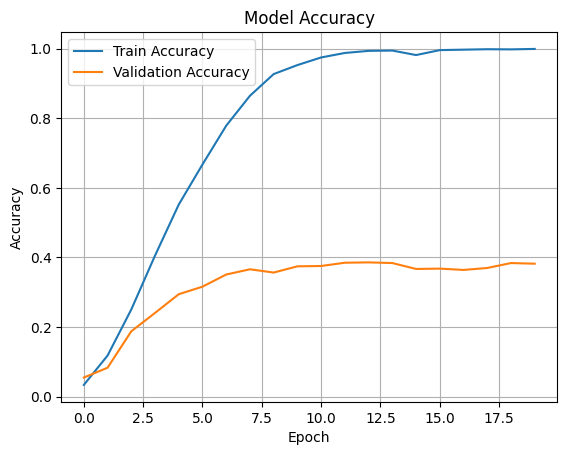

In [38]:
plt.plot(modelo_1_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_1_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
modelo_1_ByN = Sequential([
    Input(shape=(Sx,Sy,1)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_1_ByN.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_1_ByN_metrics = modelo_1_ByN.fit(x_train_ByN,y_train_ByN,validation_data= (x_valid_ByN,y_valid_ByN), epochs = epocas)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.0240 - loss: 4.6994 - val_accuracy: 0.0368 - val_loss: 3.9163
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.0899 - loss: 3.5881 - val_accuracy: 0.1047 - val_loss: 3.6357
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - accuracy: 0.2190 - loss: 2.9480 - val_accuracy: 0.1575 - val_loss: 3.3066
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.3472 - loss: 2.4483 - val_accuracy: 0.2085 - val_loss: 3.0410
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.4699 - loss: 1.9968 - val_accuracy: 0.2123 - val_loss: 2.9582
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.6037 - loss: 1.5363 - val_accuracy: 0.2689 - val_loss: 2.9180
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.7096 - loss: 1.1836 - val_accuracy: 0.2868 - val_loss: 3.0342
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.7881 - loss: 0.8862 - val_accu

In [41]:
modelo_1_ByN.evaluate(x_test_ByN, y_test_ByN)

206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5712 - loss: 3.1208


[3.1222426891326904, 0.5744972825050354]

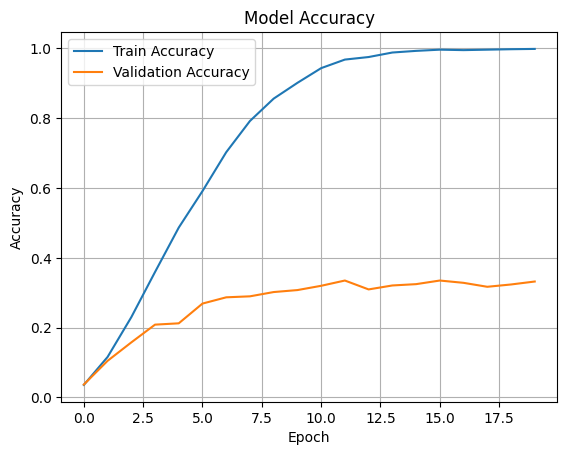

In [42]:
plt.plot(modelo_1_ByN_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_1_ByN_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
modelo_2 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_2.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_2_metrics = modelo_2.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.0544 - loss: 3.9305 - val_accuracy: 0.1585 - val_loss: 3.4193
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.2917 - loss: 2.8310 - val_accuracy: 0.3057 - val_loss: 2.7648
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.4948 - loss: 1.9446 - val_accuracy: 0.3830 - val_loss: 2.4398
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.6348 - loss: 1.3490 - val_accuracy: 0.3755 - val_loss: 2.7585
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.7375 - loss: 0.9412 - val_accuracy: 0.3915 - val_loss: 2.8192
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.8502 - loss: 0.5471 - val_accuracy: 0.4255 - val_loss: 2.8320
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.9184 - loss: 0.3057 - val_accuracy: 0.3972 - val_loss: 3.7414
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.9493 - loss: 0.2027 - val_accuracy: 0.4

In [34]:
modelo_2.evaluate(x_test_RGB, y_test_RGB)

206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6267 - loss: 3.9971


[4.304018974304199, 0.6209627985954285]